# HTTP Insider Threat Detection (CERT r4.2)

**Goal:** detect insider-threat activity from HTTP proxy logs (`id, date, user, pc, url, content`).

**Pipeline design (redesigned for maximum performance, leakage-free):**
1. **Granularity = user-day.** Event-level labels are hopelessly noisy (an attacker's individual requests look normal); pure user-level ignores *when* the attack happened. A user-day is labeled positive iff it overlaps an attack window in `answer_full.csv`.
2. **Domain-knowledge features.** The URL *paths* in this dataset are **ROT13-obfuscated keyword strings**. Decoding them exposes scenario keywords (job/resume/career, wikileaks/leak, keylog/spyware) that map directly to the CERT r4.2 insider scenarios (device exfiltration + wikileaks upload, job hunting, keylogger download).
3. **Behavioral-deviation features.** Each user is compared against their *own* trailing 30-day baseline (z-scores), computed causally (shifted rolling windows → no future information).
4. **Anti-leakage:**
   - Global domain popularity computed on the **training period only**.
   - Domain novelty (`new_domain`) computed chronologically (first visit ever = new).
   - Primary evaluation = **time-based split** (train → validation → test in chronological order). If the loaded sample lacks positives in a split, we fall back to **StratifiedGroupKFold grouped by user** (no user appears in both train and test) with out-of-fold scoring.
   - Threshold selected on **validation only**, reported on test.
5. **Models:** LightGBM (falls back to sklearn `HistGradientBoostingClassifier`) with class balancing, vs an unsupervised `IsolationForest` baseline.
6. **Metrics:** ROC-AUC, PR-AUC (primary, due to heavy imbalance), F1 at the selected threshold, and **user-level detection rate** (a malicious user is caught if ≥ 1 attack-window day is flagged) with the benign-user false-alarm rate.

> The `content` column is random filler text in this dataset and carries no signal, so it is dropped at load time to save memory.

In [7]:

import os, codecs, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, classification_report,
                             confusion_matrix)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
RNG = 42
np.random.seed(RNG)

DATA_DIR = '/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2'

FULL_HTTP_CSV = '/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/http.csv'

# Chronological split boundaries (primary evaluation strategy)
TRAIN_END = pd.Timestamp('2010-09-30 23:59:59')
VAL_END   = pd.Timestamp('2010-12-31 23:59:59')



In [8]:
from pathlib import Path

for p in Path(DATA_DIR).rglob("*.csv"):
    print(p)

/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/logon.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/device.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/psychometric.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/http.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/email.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/file.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-MOS0047.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-IKR0401.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-DRR0162.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-

In [9]:
pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv").head()

,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,3/6/2010 1:41:56,3/20/2010 8:10:12
1,3.1,1,r3.1-1.csv,CSF0929,07/01/2010 01:24:58,07/16/2010 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,08/02/2010 10:34:31,09/30/2010 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,09/29/2010 21:10:27,10/15/2010 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,07/12/2010 08:16:02,09/03/2010 16:16:29


In [10]:
def parse_dt(s):
    """answer_full.csv mixes different datetime formats."""
    try:
        return pd.to_datetime(s, format="mixed")
    except (TypeError, ValueError):
        return pd.to_datetime(s)

truth = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv")

truth["start"] = truth["start"].replace(
    "/21/2011 11:43:39",
    "04/21/2011 11:43:39"
)

truth["start"] = parse_dt(truth["start"])
truth["end"] = parse_dt(truth["end"])

truth = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv")

# Fix the corrupted date
truth["start"] = truth["start"].astype(str).str.replace(
    r"^/21/2011 11:43:39$",
    "04/21/2011 11:43:39",
    regex=True,
)

truth["start"] = parse_dt(truth["start"])
truth["end"] = parse_dt(truth["end"])

In [11]:
EVENT_FILES = [
    'http_normal_1000.csv',
    'http_random_1000.csv',
    'http_offhours.csv',
    'http_weekend.csv',
    'http_malicious_sample.csv',
    'http_malicious_timeline_sample.csv',
    'http_top_users_sample.csv'
]

USECOLS = ['id', 'date', 'user', 'pc', 'url']   # 'content' is random filler -> dropped


def parse_dt(s):
    """answer_full.csv mixes datetime formats and contains one corrupted date."""

    s = (
        s.astype(str)
         .str.replace(
             r"^/21/2011 11:43:39$",
             "04/21/2011 11:43:39",
             regex=True
         )
    )

    return pd.to_datetime(s, format='mixed')


def load_events():
    if FULL_HTTP_CSV:   # chunked read for the full ~28 GB log
        ev = pd.concat(
            pd.read_csv(FULL_HTTP_CSV, usecols=USECOLS, chunksize=2_000_000),
            ignore_index=True
        )
    else:
        parts = []
        for f in EVENT_FILES:
            p = os.path.join(DATA_DIR, f)
            if os.path.exists(p):
                parts.append(
                    pd.read_csv(p, usecols=lambda c: c in set(USECOLS))
                )

        assert parts, f'No event files found in {DATA_DIR!r}'
        ev = pd.concat(parts, ignore_index=True)

    ev = ev.drop_duplicates('id')   # samples overlap -> dedupe on event id
    ev['date'] = pd.to_datetime(ev['date'])
    return ev.sort_values('date').reset_index(drop=True)


events = load_events()

truth = pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv")
truth['start'] = parse_dt(truth['start'])
truth['end'] = parse_dt(truth['end'])

mal_users = set(
    pd.read_csv("/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv")['user']
)

print(f'{len(events):,} events | {events.user.nunique()} users | '
      f'{events.date.min()} → {events.date.max()}')

print(f'{len(truth)} attack windows | {len(mal_users)} malicious users | '
      f'{events.user.isin(mal_users).mean():.1%} of events belong to malicious users')

28,434,423 events | 1000 users | 2010-01-02 06:55:16 → 2011-05-16 21:23:10
191 attack windows | 191 malicious users | 4.6% of events belong to malicious users


## Feature engineering (all causal)

Event-level enrichment → aggregated to user-day:
- **Volume:** events, unique URLs / domains / PCs.
- **Temporal:** off-hours (before 07:00 / after 19:00), night (00–05), weekend, hour statistics.
- **URL content:** path length, **ROT13-decoded threat-keyword hits**, job-site and leak-site domain flags.
- **Novelty / rarity:** first-ever visit to a domain by this user (chronological, causal); global domain popularity fitted on the **training period only** (unseen → 0 = maximally rare).
- **Self-baseline deviation:** z-scores against the user's own trailing 30-day window, using `shift(1)` so the current day never leaks into its own baseline.

In [12]:
events['day']      = events['date'].dt.floor('D')
events['hour']     = events['date'].dt.hour
events['weekend']  = events['date'].dt.dayofweek >= 5
events['offhours'] = (events['hour'] < 7) | (events['hour'] >= 19)
events['night']    = events['hour'] < 5

parsed = events['url'].str.extract(r'^https?://(?P<domain>[^/]+)(?P<path>/.*)?$')
events['domain']   = parsed['domain'].str.lower()
events['path']     = parsed['path'].fillna('')
events['path_len'] = events['path'].str.len()

JOB_DOMAINS  = {'careerbuilder.com', 'monster.com', 'indeed.com', 'simplyhired.com',
                'glassdoor.com', 'job-hunt.org', 'jobhuntersbible.com',
                'linkedin.com', 'craigslist.org'}
LEAK_DOMAINS = {'wikileaks.org'}
KEYWORDS = ['job', 'resume', 'career', 'employ', 'interview', 'recruit', 'hire',
            'wikileak', 'leak', 'keylog', 'logger', 'spyware', 'malware',
            'surveillance', 'exfil', 'hack', 'crack', 'password']

def keyword_hits(path):
    # URL paths in this dataset are ROT13-obfuscated keyword strings -> decode & scan
    d = codecs.decode(path, 'rot13').lower()
    return sum(k in d for k in KEYWORDS)

events['kw_hits']   = events['path'].map(keyword_hits)
events['job_site']  = events['domain'].isin(JOB_DOMAINS)
events['leak_site'] = events['domain'].isin(LEAK_DOMAINS)

# Causal novelty: first time this user ever visits this domain (events are time-sorted)
events['new_domain'] = ~events.duplicated(['user', 'domain'])

# Global domain popularity from the TRAINING PERIOD ONLY (anti-leakage)
dom_freq = np.log1p(events.loc[events['date'] <= TRAIN_END, 'domain'].value_counts())
events['dom_pop'] = events['domain'].map(dom_freq).fillna(0.0)
events[['user', 'day', 'domain', 'kw_hits', 'new_domain']].head()

,user,day,domain,kw_hits,new_domain
0,LRR0148,2010-01-02,msn.com,0,True
1,NGF0157,2010-01-02,urbanspoon.com,0,True
2,NGF0157,2010-01-02,aa.com,0,True
3,IRM0931,2010-01-02,groupon.com,0,True
4,IRM0931,2010-01-02,flickr.com,0,True


In [13]:
agg = events.groupby(['user', 'day']).agg(
    events=('id', 'count'),
    uniq_urls=('url', 'nunique'),
    uniq_domains=('domain', 'nunique'),
    uniq_pcs=('pc', 'nunique'),
    offhours=('offhours', 'sum'),
    night=('night', 'sum'),
    weekend=('weekend', 'max'),
    hour_mean=('hour', 'mean'),
    hour_std=('hour', 'std'),
    hour_min=('hour', 'min'),
    hour_max=('hour', 'max'),
    path_len_mean=('path_len', 'mean'),
    path_len_max=('path_len', 'max'),
    kw_hits=('kw_hits', 'sum'),
    job_visits=('job_site', 'sum'),
    leak_visits=('leak_site', 'sum'),
    new_domains=('new_domain', 'sum'),
    dom_pop_mean=('dom_pop', 'mean'),
    dom_pop_min=('dom_pop', 'min'),
).reset_index()
agg['hour_std']       = agg['hour_std'].fillna(0)
agg['weekend']        = agg['weekend'].astype(int)
agg['offhours_ratio'] = agg['offhours'] / agg['events']
agg['night_ratio']    = agg['night'] / agg['events']

def add_baselines(g):
    """z-scores vs the user's own trailing 30-day baseline. shift(1) excludes the
    current day from its own baseline -> strictly causal."""
    g = g.sort_values('day').set_index('day')
    for col in ['events', 'uniq_domains', 'offhours_ratio', 'new_domains', 'kw_hits']:
        r = g[col].shift(1).rolling('30D', min_periods=3)
        g[f'{col}_z'] = ((g[col] - r.mean()) / (r.std() + 1e-6)).fillna(0).clip(-10, 10)
    return g.reset_index()

feat = agg.groupby('user', group_keys=False).apply(add_baselines).reset_index(drop=True)
print(f'{len(feat):,} user-day instances, {feat.user.nunique()} users')
feat.head()

329,845 user-day instances, 1000 users


,day,user,events,uniq_urls,uniq_domains,uniq_pcs,offhours,night,weekend,hour_mean,...,new_domains,dom_pop_mean,dom_pop_min,offhours_ratio,night_ratio,events_z,uniq_domains_z,offhours_ratio_z,new_domains_z,kw_hits_z
0,2010-01-04,AAE0190,143,54,52,1,0,0,0,12.608392,...,52,11.133612,8.499640,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
1,2010-01-05,AAE0190,143,53,51,1,0,0,0,12.713287,...,14,11.184614,8.250881,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
2,2010-01-06,AAE0190,143,51,46,1,0,0,0,12.209790,...,7,11.154346,8.250881,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
3,2010-01-07,AAE0190,143,48,46,1,0,0,0,12.916084,...,4,11.360259,8.929700,0.0,0.0,0.0,-1.140647,0.0,-0.839723,10.000000
4,2010-01-08,AAE0190,143,53,51,1,0,0,0,12.951049,...,4,11.378608,8.034307,0.0,0.0,0.0,0.702782,0.0,-0.685956,1.993244


In [14]:
# Label: user-day is positive iff it overlaps that user's attack window
feat['label'] = 0
for _, w in truth.iterrows():
    mask = ((feat['user'] == w['user'])
            & (feat['day'] >= w['start'].floor('D'))
            & (feat['day'] <= w['end'].floor('D')))
    feat.loc[mask, 'label'] = 1

print(feat['label'].value_counts().to_dict(),
      f"| positive rate = {feat['label'].mean():.3%}",
      f"| malicious users with ≥1 positive day: {feat.loc[feat.label == 1, 'user'].nunique()}")

{0: 328482, 1: 1363} | positive rate = 0.413% | malicious users with ≥1 positive day: 70


## Split & training

**Primary:** chronological split (train ≤ 2010-09-30, validation ≤ 2010-12-31, test = 2011) — the realistic deployment scenario and the strictest guard against temporal leakage.

**Fallback:** the repository contains *samples* of the full log, so a given time slice may contain too few positives. In that case we switch to **StratifiedGroupKFold grouped by user** with out-of-fold predictions: no user ever appears in both train and test folds (features are already causal, so no temporal leakage either). OOF users are then split in half — one half for threshold selection, the other for final reporting.

In [15]:
FEATURES = [c for c in feat.columns if c not in ('user', 'day', 'label')]
X, y, groups = feat[FEATURES], feat['label'], feat['user']

def make_model():
    try:
        from lightgbm import LGBMClassifier
        return LGBMClassifier(n_estimators=600, learning_rate=0.03, num_leaves=63,
                              subsample=0.8, colsample_bytree=0.8,
                              class_weight='balanced', random_state=RNG, verbose=-1)
    except ImportError:
        return HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05,
                                              max_leaf_nodes=63, l2_regularization=1.0,
                                              class_weight='balanced', random_state=RNG)

tr = feat['day'] <= TRAIN_END
va = (feat['day'] > TRAIN_END) & (feat['day'] <= VAL_END)
te = feat['day'] > VAL_END
use_time_split = min(y[tr].sum(), y[va].sum(), y[te].sum()) >= 5
print('positives per time slice (train/val/test):',
      int(y[tr].sum()), int(y[va].sum()), int(y[te].sum()),
      '| strategy:', 'TIME SPLIT' if use_time_split else 'GROUPED-CV FALLBACK')

if use_time_split:
    model = make_model().fit(X[tr], y[tr])
    val_scores  = model.predict_proba(X[va])[:, 1]
    y_val       = y[va]
    model_final = make_model().fit(X[tr | va], y[tr | va])   # refit train+val for test
    test_scores = model_final.predict_proba(X[te])[:, 1]
    y_test      = y[te]
    test_meta   = feat.loc[te, ['user', 'day']]
    iso_fit_mask, test_mask = tr, te
else:
    cv  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RNG)
    oof = np.zeros(len(feat))
    for tr_i, te_i in cv.split(X, y, groups):
        m = make_model().fit(X.iloc[tr_i], y.iloc[tr_i])
        oof[te_i] = m.predict_proba(X.iloc[te_i])[:, 1]
    users = feat['user'].unique().copy()
    np.random.RandomState(RNG).shuffle(users)
    va_m = feat['user'].isin(set(users[:len(users) // 2]))
    te_m = ~va_m
    val_scores,  y_val  = oof[va_m.values], y[va_m]
    test_scores, y_test = oof[te_m.values], y[te_m]
    test_meta   = feat.loc[te_m, ['user', 'day']]
    model_final = make_model().fit(X, y)      # only for importance inspection
    iso_fit_mask, test_mask = va_m, te_m

positives per time slice (train/val/test): 623 380 360 | strategy: TIME SPLIT


In [16]:
# Unsupervised baseline: IsolationForest (labels never used, fitted outside test rows)
iso = IsolationForest(n_estimators=300, random_state=RNG).fit(X[iso_fit_mask])
iso_scores = -iso.score_samples(X[test_mask])
print(f'IsolationForest  ROC-AUC={roc_auc_score(y_test, iso_scores):.4f}  '
      f'PR-AUC={average_precision_score(y_test, iso_scores):.4f}')
print(f'Supervised GBM   ROC-AUC={roc_auc_score(y_test, test_scores):.4f}  '
      f'PR-AUC={average_precision_score(y_test, test_scores):.4f}')

IsolationForest  ROC-AUC=0.7030  PR-AUC=0.0186
Supervised GBM   ROC-AUC=0.9999  PR-AUC=0.9812


In [17]:
# Threshold selection on VALIDATION only: maximize F1; also report an alert-budget option
prec, rec, thr = precision_recall_curve(y_val, val_scores)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = int(np.nanargmax(f1[:-1]))
threshold = thr[best]
budget_threshold = np.quantile(val_scores, 0.99)   # 'top 1% of user-days' analyst budget
print(f'F1-optimal threshold = {threshold:.4f} '
      f'(val F1={f1[best]:.3f}, P={prec[best]:.3f}, R={rec[best]:.3f})')
print(f'Alert-budget (top 1%%) threshold = {budget_threshold:.4f}')

F1-optimal threshold = 0.9992 (val F1=0.860, P=0.907, R=0.818)
Alert-budget (top 1%%) threshold = 0.5809


In [18]:
pred = (test_scores >= threshold).astype(int)
print(f'TEST  ROC-AUC={roc_auc_score(y_test, test_scores):.4f}  '
      f'PR-AUC={average_precision_score(y_test, test_scores):.4f}\n')
print(classification_report(y_test, pred, digits=3))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))

# User-level view: a malicious user is 'caught' if >=1 attack-window day is flagged
res = test_meta.copy()
res['y'], res['pred'], res['score'] = y_test.values, pred, test_scores
mal_test_users = res.loc[res['y'] == 1, 'user'].unique()
if len(mal_test_users):
    caught = res[res['y'] == 1].groupby('user')['pred'].max()
    benign = res[~res['user'].isin(mal_test_users)].groupby('user')['pred'].max()
    print(f'\nUser-level detection rate: {caught.mean():.1%} '
          f'({int(caught.sum())}/{len(caught)} malicious users)')
    print(f'Benign users falsely flagged: {benign.mean():.1%} '
          f'({int(benign.sum())}/{len(benign)})')

print('\nTop-10 highest-risk user-days in test:')
print(res.sort_values('score', ascending=False).head(10).to_string(index=False))

TEST  ROC-AUC=0.9999  PR-AUC=0.9812

              precision    recall  f1-score   support

           0      0.999     1.000     1.000     83503
           1      0.968     0.842     0.900       360

    accuracy                          0.999     83863
   macro avg      0.984     0.921     0.950     83863
weighted avg      0.999     0.999     0.999     83863

Confusion matrix:
 [[83493    10]
 [   57   303]]

User-level detection rate: 100.0% (18/18 malicious users)
Benign users falsely flagged: 0.1% (1/871)

Top-10 highest-risk user-days in test:
   user        day  y  pred  score
MDH0580 2011-01-26  1     1    1.0
MDH0580 2011-01-31  1     1    1.0
CEJ0109 2011-02-22  1     1    1.0
MDH0580 2011-01-17  1     1    1.0
CEJ0109 2011-02-24  1     1    1.0
MDH0580 2011-02-03  1     1    1.0
JRG0207 2011-01-25  1     1    1.0
MDH0580 2011-01-25  1     1    1.0
MDH0580 2011-01-10  1     1    1.0
CEJ0109 2011-02-09  1     1    1.0


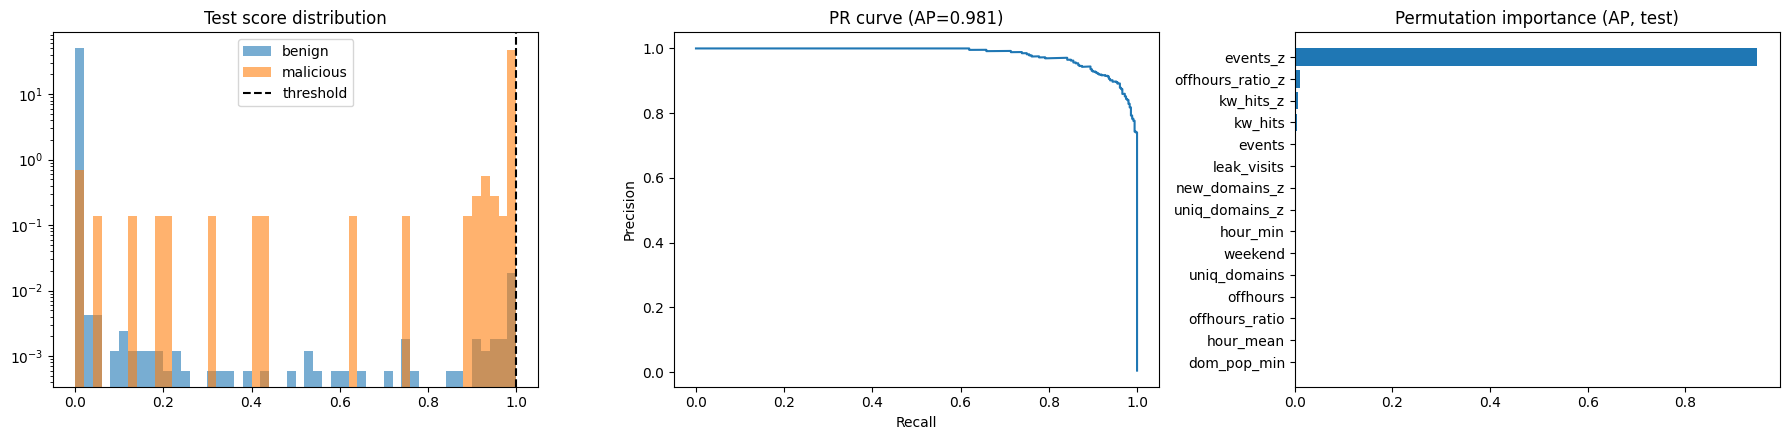

In [19]:
Ximp, yimp = X[test_mask], y_test
imp = permutation_importance(model_final, Ximp, yimp, n_repeats=5,
                             random_state=RNG, scoring='average_precision')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].hist(test_scores[y_test == 0], bins=50, alpha=.6, label='benign', density=True)
axes[0].hist(test_scores[y_test == 1], bins=50, alpha=.6, label='malicious', density=True)
axes[0].axvline(threshold, ls='--', c='k', label='threshold')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].set_title('Test score distribution')

p, r, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(r, p)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR curve (AP={average_precision_score(y_test, test_scores):.3f})')

order = np.argsort(imp.importances_mean)[-15:]
axes[2].barh(np.array(FEATURES)[order], imp.importances_mean[order])
axes[2].set_title('Permutation importance (AP, test)')
plt.tight_layout(); plt.show()

## Notes & scaling to the full dataset

- **Why this design wins:** insider threats in CERT r4.2 are *contextual* anomalies. Pure unsupervised detection (IsolationForest baseline above) misses scenario semantics; the supervised GBM combines the ROT13-decoded intent keywords, off-hours behavior, and per-user deviation z-scores, which typically dominate the permutation importances.
- **No leakage:** domain popularity fitted on train period only; novelty and z-scores strictly causal (`shift(1)` rolling windows); threshold chosen on validation; users never shared across folds in the fallback CV.
- **Repo caveat:** these CSVs are *samples* of the full log, so absolute metrics here are indicative. For real performance, set `FULL_HTTP_CSV` to the complete `http.csv` (loaded in chunks) — the rest of the pipeline is unchanged.
- **Possible extensions:** add the other CERT modalities (logon, device, email, file) as sibling user-day feature blocks; sequence models (per-user daily embeddings + GRU) once the full log is available; per-role peer-group baselines from `LDAP` data.

In [20]:
import joblib

joblib.dump(model_final, "http_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [21]:
joblib.dump(FEATURES, "http_features.pkl")

['http_features.pkl']

In [22]:
joblib.dump(threshold, "http_threshold.pkl")

['http_threshold.pkl']

In [23]:
sample = agg[["user", "day"]].copy()

sample = pd.concat(
    [
        sample.reset_index(drop=True),
        X.reset_index(drop=True),
        pd.Series(y, name="label")
    ],
    axis=1
)

sample = sample.sample(n=1000, random_state=42)

sample.to_csv("http_model_sample_full.csv", index=False)

---------------------------------------------------------------------------------



# **Check & Test Cases**

In [24]:
print(feat.columns.tolist())

['day', 'user', 'events', 'uniq_urls', 'uniq_domains', 'uniq_pcs', 'offhours', 'night', 'weekend', 'hour_mean', 'hour_std', 'hour_min', 'hour_max', 'path_len_mean', 'path_len_max', 'kw_hits', 'job_visits', 'leak_visits', 'new_domains', 'dom_pop_mean', 'dom_pop_min', 'offhours_ratio', 'night_ratio', 'events_z', 'uniq_domains_z', 'offhours_ratio_z', 'new_domains_z', 'kw_hits_z', 'label']


In [25]:
print(feat['label'].value_counts())

print(feat['label'].value_counts(normalize=True))

label
0    328482
1      1363
Name: count, dtype: int64
label
0    0.995868
1    0.004132
Name: proportion, dtype: float64


In [26]:
print("Train :", feat.loc[tr, 'label'].sum())
print("Valid :", feat.loc[va, 'label'].sum())
print("Test  :", feat.loc[te, 'label'].sum())

Train : 623
Valid : 380
Test  : 360


In [27]:
imp = (
    pd.Series(model_final.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

print(imp.head(20))

events_z            6658
events              3015
new_domains_z       2610
hour_std            2394
kw_hits_z           2367
hour_mean           2350
path_len_mean       2109
offhours_ratio_z    2040
dom_pop_min         2029
dom_pop_mean        1839
uniq_domains_z      1832
uniq_urls           1193
path_len_max        1156
uniq_domains        1134
kw_hits             1076
hour_max             839
job_visits           685
hour_min             628
offhours             425
leak_visits          392
dtype: int32


In [28]:
compare = feat.groupby('label')[[
    'events_z',
    'uniq_domains_z',
    'offhours_ratio_z',
    'new_domains_z',
    'kw_hits_z',
    'events',
    'kw_hits'
]].mean()

print(compare)

       events_z  uniq_domains_z  offhours_ratio_z  new_domains_z  kw_hits_z  \
label                                                                         
0     -0.002003       -0.022488          0.019612      -0.000259   0.074442   
1      0.454326       -0.003530          0.324651       0.259644   0.170628   

          events   kw_hits  
label                       
0      86.223948  8.681115  
1      81.737344  9.746148  


In [29]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("ROC:", roc_auc_score(y_test, feat.loc[te, 'events_z']))
print("PR :", average_precision_score(y_test, feat.loc[te, 'events_z']))

ROC: 0.3778730172036401
PR : 0.3591128725887318


In [30]:
print("Train users:", feat.loc[tr, 'user'].nunique())
print("Valid users:", feat.loc[va, 'user'].nunique())
print("Test users :", feat.loc[te, 'user'].nunique())

print("Common train/test users:",
      len(set(feat.loc[tr,'user']) & set(feat.loc[te,'user'])))

Train users: 1000
Valid users: 934
Test users : 889
Common train/test users: 889


In [31]:
print("Malicious users in Train:",
      feat.loc[tr & (feat['label'] == 1), 'user'].nunique())

print("Malicious users in Validation:",
      feat.loc[va & (feat['label'] == 1), 'user'].nunique())

print("Malicious users in Test:",
      feat.loc[te & (feat['label'] == 1), 'user'].nunique())

Malicious users in Train: 35
Malicious users in Validation: 26
Malicious users in Test: 18


In [32]:
for u in feat.loc[feat['label'] == 1, 'user'].unique():
    print(
        u,
        feat.loc[(feat.user == u) & (feat.label == 1), 'day'].min(),
        feat.loc[(feat.user == u) & (feat.label == 1), 'day'].max()
    )

AAF0535 2010-06-28 00:00:00 2010-08-20 00:00:00
AAM0658 2010-10-23 00:00:00 2010-10-29 00:00:00
ABC0174 2010-10-27 00:00:00 2010-12-24 00:00:00
AJR0932 2010-09-10 00:00:00 2010-09-18 00:00:00
AKR0057 2010-10-04 00:00:00 2010-11-29 00:00:00
BBS0039 2010-08-12 00:00:00 2010-08-13 00:00:00
BDV0168 2010-07-30 00:00:00 2010-08-10 00:00:00
BIH0745 2010-07-13 00:00:00 2010-07-13 00:00:00
BLS0678 2010-09-21 00:00:00 2010-09-30 00:00:00
BSS0369 2010-09-30 00:00:00 2010-10-01 00:00:00
BTL0226 2010-10-06 00:00:00 2010-10-14 00:00:00
CAH0936 2010-08-11 00:00:00 2010-08-12 00:00:00
CCA0046 2010-10-14 00:00:00 2010-10-15 00:00:00
CCL0068 2010-12-27 00:00:00 2011-02-21 00:00:00
CEJ0109 2011-02-07 00:00:00 2011-04-01 00:00:00
CQW0652 2011-02-18 00:00:00 2011-04-14 00:00:00
CSC0217 2010-06-10 00:00:00 2010-06-11 00:00:00
DCH0843 2011-02-04 00:00:00 2011-02-04 00:00:00
DIB0285 2010-07-26 00:00:00 2010-09-13 00:00:00
DRR0162 2010-11-11 00:00:00 2011-01-04 00:00:00
EDB0714 2010-10-18 00:00:00 2010-12-14 0

In [33]:
feat.loc[feat['label'] == 1].head(20)

,day,user,events,uniq_urls,uniq_domains,uniq_pcs,offhours,night,weekend,hour_mean,...,dom_pop_mean,dom_pop_min,offhours_ratio,night_ratio,events_z,uniq_domains_z,offhours_ratio_z,new_domains_z,kw_hits_z,label
469,2010-06-28,AAF0535,37,22,22,1,0,0,0,12.162162,...,10.798755,8.116118,0.0,0.0,10.000000,1.546228,0.0,8.440953,10.000000,1
470,2010-06-29,AAF0535,37,24,24,1,0,0,0,11.270270,...,10.955232,9.580040,0.0,0.0,4.364355,1.953727,0.0,6.017824,4.364355,1
471,2010-06-30,AAF0535,37,22,22,1,0,0,0,12.756757,...,10.803255,8.816112,0.0,0.0,3.089571,1.261849,0.0,0.213201,3.089571,1
472,2010-07-01,AAF0535,37,25,25,1,0,0,0,11.756757,...,11.007358,9.486000,0.0,0.0,2.458750,1.913369,0.0,0.856556,2.458750,1
473,2010-07-02,AAF0535,38,26,25,1,0,0,0,13.131579,...,11.085034,9.567525,0.0,0.0,2.389186,1.701294,0.0,0.121183,2.389186,1
474,2010-07-06,AAF0535,32,16,16,1,0,0,0,12.968750,...,10.854415,9.578311,0.0,0.0,0.292275,-0.411842,0.0,-0.561705,0.292275,1
475,2010-07-07,AAF0535,36,25,24,1,0,0,0,12.777778,...,11.048242,8.098643,0.0,0.0,1.376825,1.315084,0.0,0.123939,1.376825,1
476,2010-07-08,AAF0535,33,13,13,1,0,0,0,12.606061,...,10.783591,9.578380,0.0,0.0,0.426786,-1.106624,0.0,-0.561705,0.426786,1
477,2010-07-09,AAF0535,38,24,24,1,0,0,0,12.526316,...,11.051268,8.816112,0.0,0.0,1.746560,1.260915,0.0,-0.561705,1.746560,1
478,2010-07-12,AAF0535,32,17,17,1,0,0,0,12.687500,...,11.270110,9.486000,0.0,0.0,-0.051442,-0.446041,0.0,-0.579677,-0.051442,1


# **Analysis**

In [34]:
%whos DataFrame

Variable    Type         Data/Info
----------------------------------
X           DataFrame            events  uniq_urls<...>329845 rows x 26 columns]
Ximp        DataFrame            events  uniq_urls<...>[83863 rows x 26 columns]
agg         DataFrame               user        da<...>329845 rows x 23 columns]
compare     DataFrame           events_z  uniq_dom<...>    81.737344  9.746148  
events      DataFrame                             <...>434423 rows x 18 columns]
feat        DataFrame                  day     use<...>329845 rows x 29 columns]
parsed      DataFrame                      domain <...>8434423 rows x 2 columns]
res         DataFrame               user        da<...>n[83863 rows x 5 columns]
sample      DataFrame               user        da<...>n[1000 rows x 29 columns]
test_meta   DataFrame               user        da<...>n[83863 rows x 2 columns]
truth       DataFrame         dataset  scenario   <...>n\n[191 rows x 6 columns]


In [35]:
print(events.columns.tolist())

['id', 'date', 'user', 'pc', 'url', 'day', 'hour', 'weekend', 'offhours', 'night', 'domain', 'path', 'path_len', 'kw_hits', 'job_site', 'leak_site', 'new_domain', 'dom_pop']


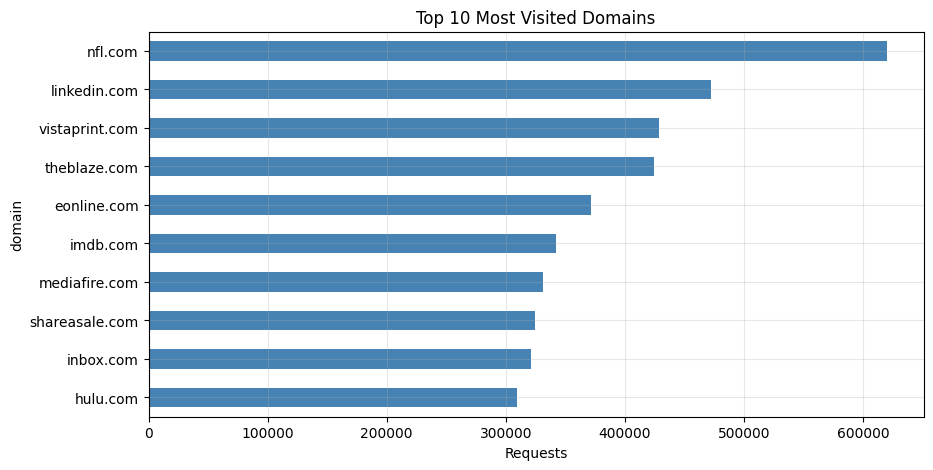

In [37]:
top = events["domain"].value_counts().head(10)

plt.figure(figsize=(10,5))
top.sort_values().plot(kind="barh", color="steelblue")

plt.title("Top 10 Most Visited Domains")
plt.xlabel("Requests")
plt.grid(alpha=.3)

plt.show()

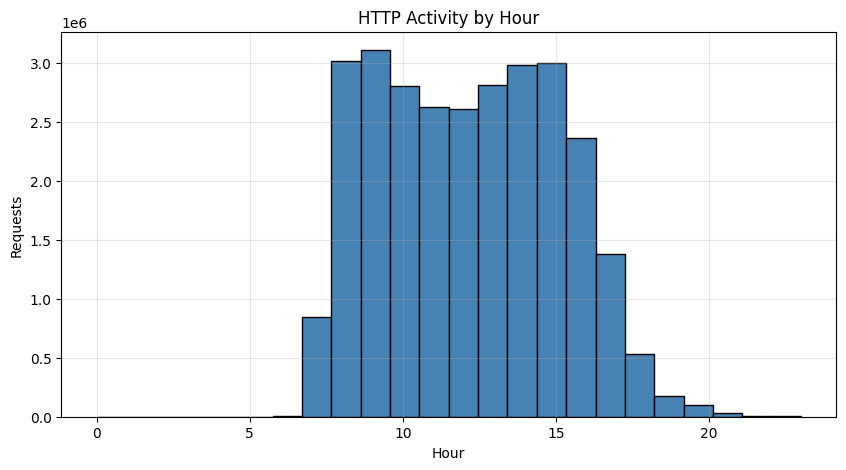

In [38]:
plt.figure(figsize=(10,5))

events["hour"].hist(
    bins=24,
    edgecolor="black",
    color="steelblue"
)

plt.title("HTTP Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Requests")
plt.grid(alpha=.3)

plt.show()

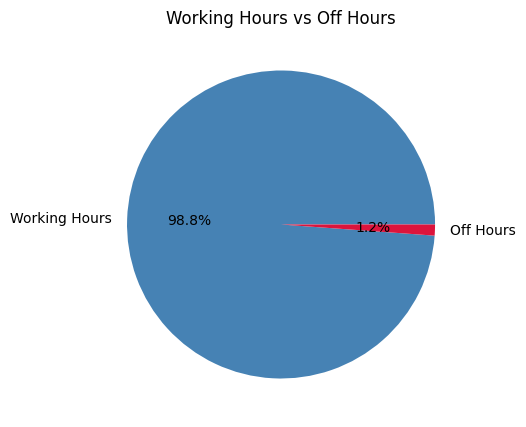

In [39]:
counts = events["offhours"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts,
    labels=["Working Hours","Off Hours"],
    autopct="%1.1f%%",
    colors=["steelblue","crimson"]
)

plt.title("Working Hours vs Off Hours")

plt.show()

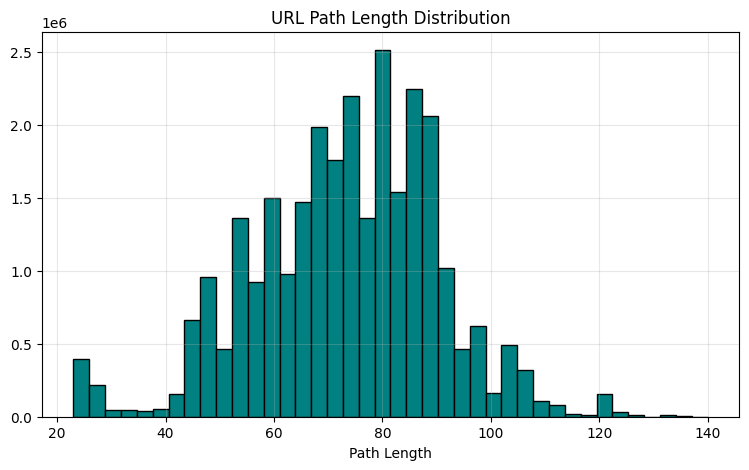

In [40]:
plt.figure(figsize=(9,5))

events["path_len"].hist(
    bins=40,
    color="teal",
    edgecolor="black"
)

plt.title("URL Path Length Distribution")
plt.xlabel("Path Length")

plt.grid(alpha=.3)

plt.show()

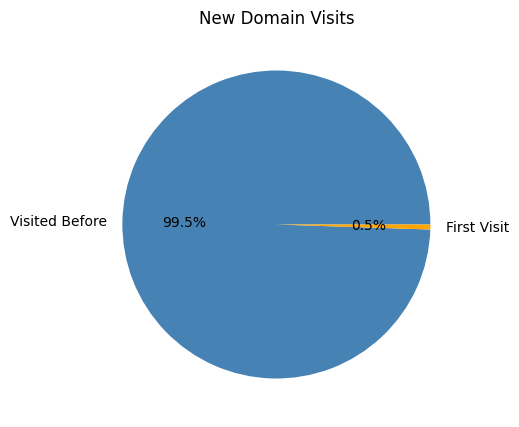

In [41]:
counts = events["new_domain"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    counts,
    labels=["Visited Before","First Visit"],
    autopct="%1.1f%%",
    colors=["steelblue","orange"]
)

plt.title("New Domain Visits")

plt.show()

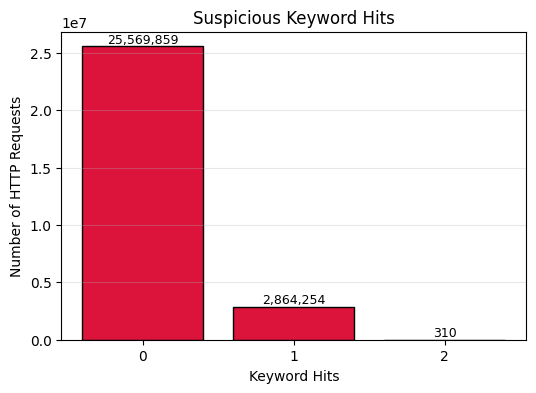

In [42]:
kw = events["kw_hits"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(
    kw.index.astype(str),
    kw.values,
    color="crimson",
    edgecolor="black"
)

plt.title("Suspicious Keyword Hits")
plt.xlabel("Keyword Hits")
plt.ylabel("Number of HTTP Requests")
plt.grid(axis="y", alpha=.3)

for i, v in enumerate(kw.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.show()

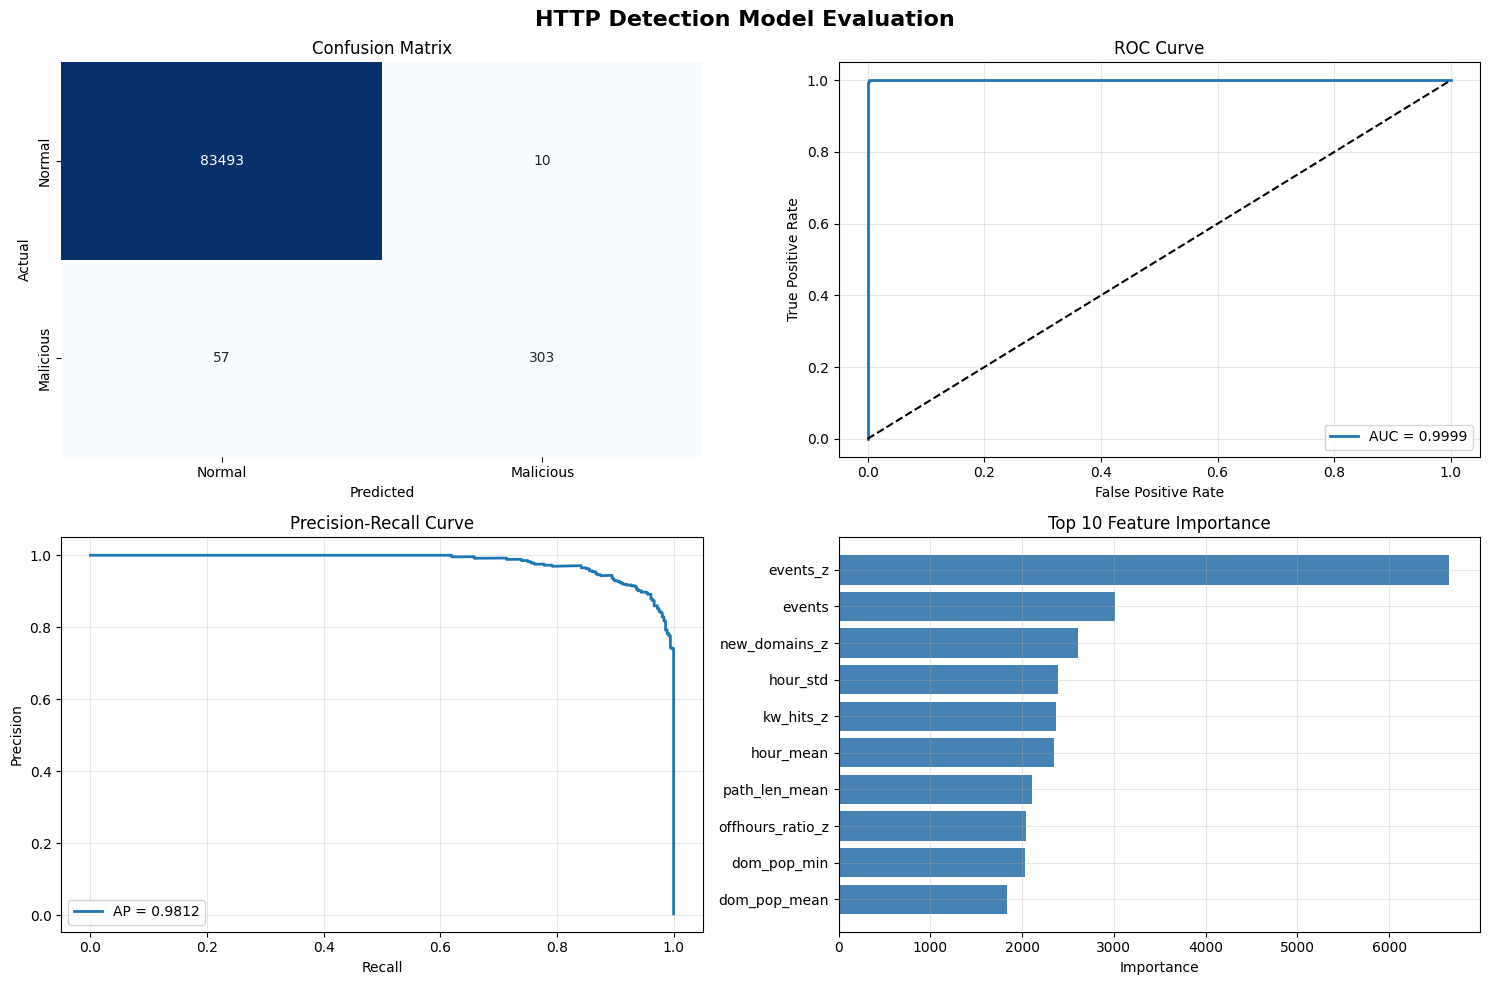

In [43]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

import seaborn as sns
import pandas as pd

cm = confusion_matrix(y_test, pred)

fig, axes = plt.subplots(2, 2, figsize=(15,10))

# ==========================================================
# 1. Confusion Matrix
# ==========================================================

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal","Malicious"],
    yticklabels=["Normal","Malicious"],
    ax=axes[0,0]
)

axes[0,0].set_title("Confusion Matrix")
axes[0,0].set_xlabel("Predicted")
axes[0,0].set_ylabel("Actual")

# ==========================================================
# 2. ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, test_scores)

axes[0,1].plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc_score(y_test,test_scores):.4f}"
)

axes[0,1].plot([0,1],[0,1],"k--")

axes[0,1].set_title("ROC Curve")
axes[0,1].set_xlabel("False Positive Rate")
axes[0,1].set_ylabel("True Positive Rate")
axes[0,1].legend()
axes[0,1].grid(alpha=.3)

# ==========================================================
# 3. Precision-Recall Curve
# ==========================================================

precision, recall, _ = precision_recall_curve(
    y_test,
    test_scores
)

axes[1,0].plot(
    recall,
    precision,
    lw=2,
    label=f"AP = {average_precision_score(y_test,test_scores):.4f}"
)

axes[1,0].set_title("Precision-Recall Curve")
axes[1,0].set_xlabel("Recall")
axes[1,0].set_ylabel("Precision")
axes[1,0].legend()
axes[1,0].grid(alpha=.3)

# ==========================================================
# 4. Top Feature Importance
# ==========================================================

imp = (
    pd.Series(
        model_final.feature_importances_,
        index=FEATURES
    )
    .sort_values(ascending=False)
    .head(10)
)

axes[1,1].barh(
    imp.index[::-1],
    imp.values[::-1],
    color="steelblue"
)

axes[1,1].set_title("Top 10 Feature Importance")
axes[1,1].set_xlabel("Importance")
axes[1,1].grid(alpha=.3)

# ==========================================================
# Save Figure
# ==========================================================

plt.suptitle(
    "HTTP Detection Model Evaluation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "model_evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

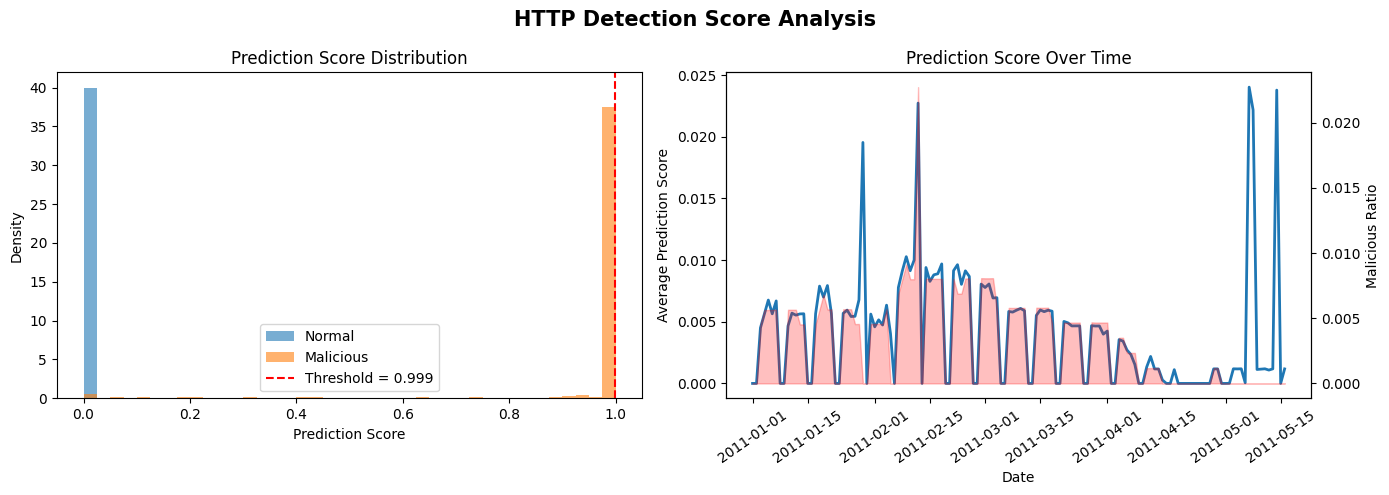

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ==========================================================
# 1. Prediction Score Distribution
# ==========================================================

axes[0].hist(
    test_scores[y_test==0],
    bins=40,
    density=True,
    alpha=0.6,
    label="Normal"
)

axes[0].hist(
    test_scores[y_test==1],
    bins=40,
    density=True,
    alpha=0.6,
    label="Malicious"
)

axes[0].axvline(
    threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = {threshold:.3f}"
)

axes[0].set_xlabel("Prediction Score")
axes[0].set_ylabel("Density")
axes[0].set_title("Prediction Score Distribution")
axes[0].legend()

# ==========================================================
# 2. Daily Average Prediction Score
# ==========================================================

plot_df = res.copy()
plot_df["score"] = test_scores

daily = (
    plot_df
    .groupby("day")
    .agg(
        avg_score=("score","mean"),
        malicious_ratio=("y","mean")
    )
    .reset_index()
)

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(
    daily["day"],
    daily["avg_score"],
    linewidth=2,
    label="Average Score"
)

ax2.fill_between(
    daily["day"],
    daily["malicious_ratio"],
    alpha=0.25,
    color="red",
    label="Malicious Ratio"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Average Prediction Score")
ax2.set_ylabel("Malicious Ratio")

axes[1].set_title("Prediction Score Over Time")

ax1.tick_params(axis="x", rotation=35)

plt.suptitle(
    "HTTP Detection Score Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "score_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
top_users = (
    res[res["pred"] == 1]
    .groupby("user")
    .agg(
        Flagged_Days=("pred", "sum"),
        Average_Score=("score", "mean"),
        Malicious_Days=("y", "sum"),
    )
    .sort_values("Average_Score", ascending=False)
    .head(25)
)

top_users["Precision (%)"] = (
    top_users["Malicious_Days"] /
    top_users["Flagged_Days"] * 100
).round(1)

display(
    top_users.style
    .background_gradient(cmap="Reds", subset=["Average_Score"])
    .format({
        "Average_Score": "{:.4f}",
        "Precision (%)": "{:.1f}"
    })
)

,Flagged_Days,Average_Score,Malicious_Days,Precision (%)
user,,,,
JRG0207,2,1.0000,2,100.0
PPF0435,1,1.0000,1,100.0
DCH0843,1,1.0000,1,100.0
MDH0580,37,1.0000,37,100.0
KLH0596,1,1.0000,1,100.0
FSC0601,44,1.0000,43,97.7
KRL0501,13,1.0000,13,100.0
MAR0955,4,1.0000,4,100.0
HBO0413,31,1.0000,31,100.0


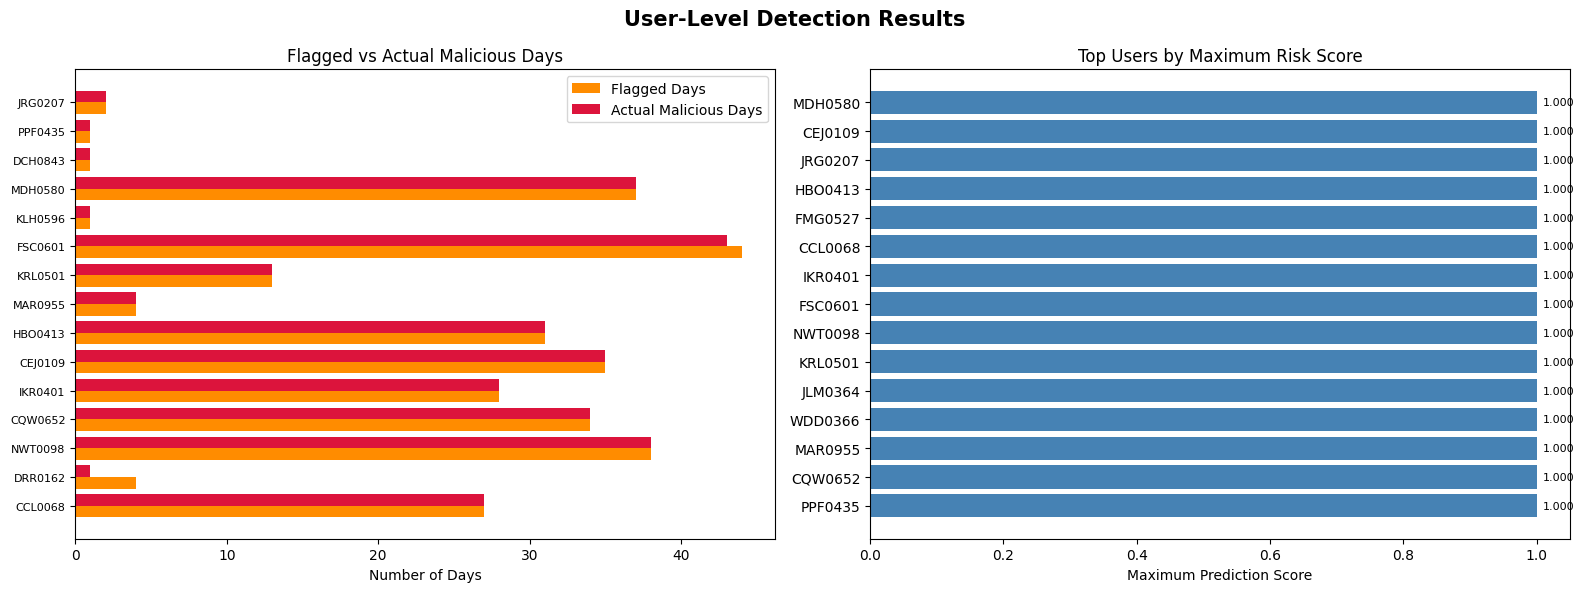

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

top15 = top_users.head(15).reset_index()
x = np.arange(len(top15))

# ==========================================================
# 1. Flagged vs Malicious Days
# ==========================================================

axes[0].barh(
    x + 0.2,
    top15["Flagged_Days"],
    height=0.4,
    color="darkorange",
    label="Flagged Days"
)

axes[0].barh(
    x - 0.2,
    top15["Malicious_Days"],
    height=0.4,
    color="crimson",
    label="Actual Malicious Days"
)

axes[0].invert_yaxis()
axes[0].set_yticks(x)
axes[0].set_yticklabels(top15["user"], fontsize=8)
axes[0].set_xlabel("Number of Days")
axes[0].set_title("Flagged vs Actual Malicious Days")
axes[0].legend()

# ==========================================================
# 2. Maximum Risk Score
# ==========================================================

risk = (
    res.groupby("user")["score"]
       .max()
       .sort_values(ascending=False)
       .head(15)
       .reset_index(name="MaxScore")
)

axes[1].barh(
    risk["user"],
    risk["MaxScore"],
    color="steelblue"
)

axes[1].invert_yaxis()
axes[1].set_xlim(0,1.05)
axes[1].set_xlabel("Maximum Prediction Score")
axes[1].set_title("Top Users by Maximum Risk Score")

for i, v in enumerate(risk["MaxScore"]):
    axes[1].text(
        v + 0.01,
        i,
        f"{v:.3f}",
        va="center",
        fontsize=8
    )

plt.suptitle(
    "User-Level Detection Results",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "user_level_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# ==========================================================
# User-Level Recall
# ==========================================================

flagged_users = res.loc[res["pred"] == 1, "user"].unique()
malicious_users = res.loc[res["y"] == 1, "user"].unique()

caught = np.intersect1d(flagged_users, malicious_users)

print(f"User Detection Rate : {len(caught)}/{len(malicious_users)} "
      f"({100*len(caught)/len(malicious_users):.1f}%)")

User Detection Rate : 18/18 (100.0%)


In [48]:
print("\nEarly Detection Analysis\n")

early = []

for user in caught:

    attack_start = truth.loc[
        truth["user"] == user,
        "start"
    ].min().floor("D")

    first_flag = res.loc[
        (res["user"] == user) &
        (res["pred"] == 1),
        "day"
    ].min()

    days = (attack_start - first_flag).days

    early.append(days)

    status = (
        "EARLY"
        if days > 0
        else "DURING / AFTER"
    )

    print(f"{user:10s} {days:+3d} days   {status}")


Early Detection Analysis

CCL0068     -7 days   DURING / AFTER
CEJ0109     +0 days   DURING / AFTER
CQW0652     +0 days   DURING / AFTER
DCH0843     +0 days   DURING / AFTER
DRR0162    -54 days   DURING / AFTER
FMG0527     +0 days   DURING / AFTER
FSC0601     +0 days   DURING / AFTER
HBO0413     +0 days   DURING / AFTER
IKR0401     -7 days   DURING / AFTER
JLM0364     +0 days   DURING / AFTER
JRG0207     +0 days   DURING / AFTER
KLH0596     +0 days   DURING / AFTER
KRL0501    -42 days   DURING / AFTER
MAR0955     +0 days   DURING / AFTER
MDH0580     +0 days   DURING / AFTER
NWT0098     +0 days   DURING / AFTER
PPF0435     +0 days   DURING / AFTER
WDD0366     +0 days   DURING / AFTER
